In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
from ncs.sparse_signal_generator import generate_tree_sparse_coeffs
import numpy as np
from tqdm import tqdm

from ncs.compressed_sensing_module import measure_and_reconstruct
from ncs.wavelet_module import inverse_transform

In [19]:
n_power = 10  # signal length 1024
n = 2 ** n_power
tree_sparsity = 10  # 1%
wavelet = 'haar'

signal_count = 5
reconstruction_attempts = 2

In [20]:
sparse_coeffs = generate_tree_sparse_coeffs(
    power=n_power,
    count=signal_count,
    tree_sparsity=tree_sparsity,
    wavelet=wavelet,
)

In [38]:

import matplotlib.pyplot as plt
import pandas as pd

measurement_mode = "gaussian"
reconstruction_mode = "CoSaMP"

# Generate m values using linspace (from 1 to n with fewer iterations)
num_m_values = 20
m_values = np.linspace(15, 200, num_m_values, dtype=int)

# Store results for each m
results = []

for m in tqdm(m_values, desc="Measuring and reconstructing"):
    for sparse_coeff in sparse_coeffs:
        for _ in range(reconstruction_attempts):
            x_hat = measure_and_reconstruct(
                measurement_mode=measurement_mode,
                m=int(m),
                reconstruction_mode=reconstruction_mode,
                coeffs_x=sparse_coeff,
                target_tree_sparsity=tree_sparsity,
            )

            sparse_z = inverse_transform(sparse_coeff)
            reconstructed_z = inverse_transform(x_hat)

            missed_support_len = len(sparse_coeff.support - x_hat.support)
            mse = np.mean((sparse_z - reconstructed_z) ** 2)

            results.append({
                'm': m,
                'mse': mse,
                'missed_support': missed_support_len
            })

# Convert to DataFrame for easier plotting
df = pd.DataFrame(results)
print(f"\nTotal experiments: {len(df)}")
print(f"MSE range: {df['mse'].min():.2f} - {df['mse'].max():.2f}")
print(f"Missed support range: {df['missed_support'].min()} - {df['missed_support'].max()}")

Measuring and reconstructing: 100%|██████████| 20/20 [01:13<00:00,  3.66s/it]


Total experiments: 200
MSE range: 11.42 - 4352.13
Missed support range: 0 - 8


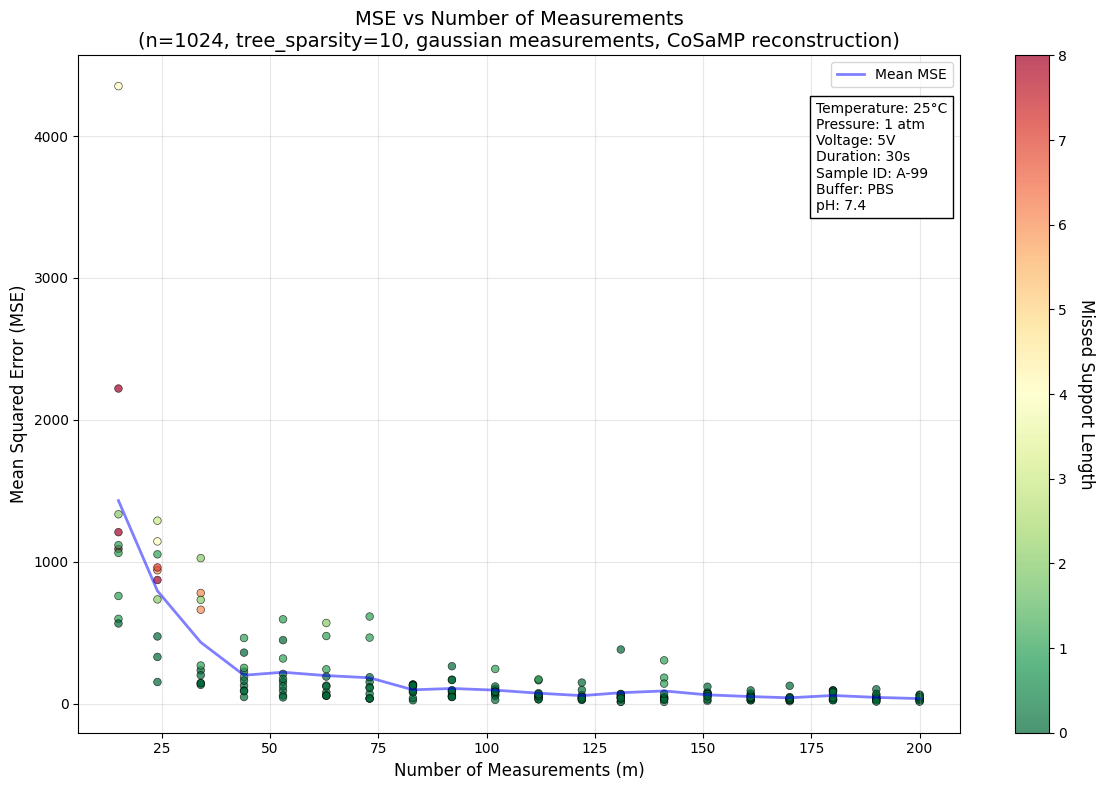

In [47]:
from matplotlib.offsetbox import AnchoredText



fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot with color mapping for missed support
scatter = ax.scatter(
    x=df['m'],
    y=df['mse'],
    c=df['missed_support'],
    cmap='RdYlGn_r',  # Red for high missed support, green for low
    vmin=0,
    vmax=df['missed_support'].max(),
    s=30,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

# Add line plot connecting the mean values per m
mean_df = df.groupby('m').agg({'mse': 'mean', 'missed_support': 'mean'}).reset_index()
ax.plot(mean_df['m'], mean_df['mse'], 'b-', linewidth=2, alpha=0.5, label='Mean MSE')

# Add colorbar for missed support
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Missed Support Length', rotation=270, labelpad=20, fontsize=12)

# Labels and title
ax.set_xlabel('Number of Measurements (m)', fontsize=12)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax.set_title(f'MSE vs Number of Measurements\n(n={n}, tree_sparsity={tree_sparsity}, {measurement_mode} measurements, {reconstruction_mode} reconstruction)',
             fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

at = AnchoredText(param_str,
                  loc='upper right',  # Align the box's top-right corner...
                  bbox_to_anchor=(1, 0.95), # ...to this point (x=1.0, y=0.75)
                  bbox_transform=ax.transAxes, # Use axes coordinates (0 to 1)
                  frameon=True
                  )

ax.add_artist(at)

plt.tight_layout()
plt.show()


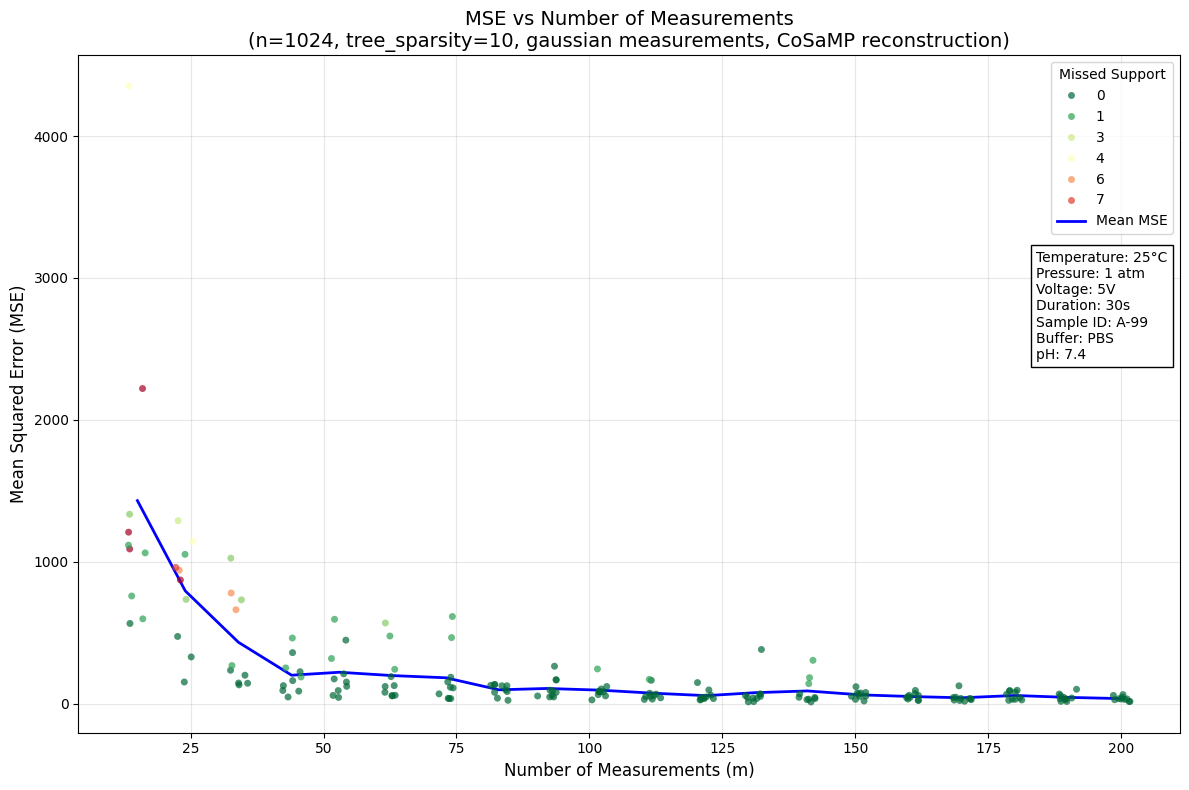

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the plot
params = {
    "Temperature": "25°C",
    "Pressure": "1 atm",
    "Voltage": "5V",
    "Duration": "30s",
    "Sample ID": "A-99",
    "Buffer": "PBS",
    "pH": 7.4
}

# 3. Create a formatted string for the box
param_str = "\n".join([f"{k}: {v}" for k, v in params.items()])

fig, ax = plt.subplots(figsize=(12, 8))

# 1. Add native_scale=True here
sns.stripplot(data=df, x='m', y='mse', hue='missed_support',
              jitter=0.2,
              alpha=0.7,
              palette='RdYlGn_r',
              native_scale=True,
              ax=ax)

# 2. The line plot remains the same
sns.lineplot(data=df, x='m', y='mse',
             estimator='mean', color='blue', linewidth=2,
             errorbar=None, ax=ax, label='Mean MSE')

# Labels and title
ax.set_xlabel('Number of Measurements (m)', fontsize=12)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax.set_title(f'MSE vs Number of Measurements\n(n={n}, tree_sparsity={tree_sparsity}, {measurement_mode} measurements, {reconstruction_mode} reconstruction)',
             fontsize=14)
ax.grid(True, alpha=0.3)

ax.legend(title='Missed Support', fontsize=10, loc='upper right')

# 2. Text Box is manually forced lower
from matplotlib.offsetbox import AnchoredText # Make sure you have this import

at = AnchoredText(param_str,
                  loc='upper right',   # We still grab the box by its top-right corner...
                  bbox_to_anchor=(1, 0.73), # ...but we pin it to 60% up the axis height
                  bbox_transform=ax.transAxes,
                  frameon=True)

ax.add_artist(at)

plt.tight_layout()
plt.show()